# Статистика по ручной разметке

### Что мы хотим исследовать:

1. Какие вообще теги самые частотные из всех? График частотности
2. Частотность тегов в текстах (столбчатая д.)
3. Частотность тегов в картинках (столбчатая д.)
4. Процент совпадения тегов (текст-картинка)
5. Какие теги чаще совпадают? Какие реже, кроме АА?
6. Heatmap для комбинаций ценностей в текстах
7. Heatmap для комбинаций ценностей в картинках
8. Где в среднем больше тегов на новость, в тексте или в картинке?
9. Связь между типом новости и типом отношения текст-картинка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation
from collections import Counter
import re

In [4]:
df = pd.read_csv('news values data - rus (2).csv', encoding='utf-8')
df.head(2)

,title,source,link,image,message,values_text,values_image,relation,news_type,Комментарии
0,"""Они все погибнут"". Что угрожает жителям север...",Риа Новости,https://ria.ru/20251008/dikson-2046918271.html,NaN,"""Они все погибнут"". Что угрожает жителям север...",Elite\nImp\nNeg\nProx\nTime,Imp\nNeg,Extension,будущее экологии,NaN
1,Компания GRASS высадила 300-тысячное дерево в ...,Риа Новости,https://ria.ru/20251009/derevo-2047273893.html,NaN,Компания GRASS закончила четырехлетнюю экопрог...,Elite\nImp\nPos\nSuper\nTime,AA\nPos,Extension,недавнее событие,NaN


In [5]:
df = df.drop(['link', 'image', 'message', 'Комментарии'], axis=1)
df.tail(2)

,title,source,values_text,values_image,relation,news_type
98,В США могут закрыть тюрьму «Аллигатор Алькатра...,Известия,Elite\nPos\nImp,AA\nProx,Modification,будущее экологии
99,Евфрат стремительно высыхает. В Библии это пре...,РБК,Imp\nNeg\nTime\n,Super\nProx,Extension,будущее экологии


# 1. Самые частотные теги

In [6]:
text_all = ' '.join(df['values_text'].fillna('').astype(str))
image_all = ' '.join(df['values_image'].fillna('').astype(str))
combined = text_all + ' ' + image_all

combined = combined.replace('\n', ' ')
combined = ' '.join(combined.split())

tags = combined.split()
tag_counts = Counter(tags)

for tag, count in sorted(tag_counts.items(), key=lambda x: x[1], reverse=True):
    print(f'{tag}: {count}')


Imp: 76
Neg: 71
Elite: 65
Time: 60
Pos: 47
Super: 42
AA: 37
Pers: 33
Prox: 31
Cons: 31
Unexp: 30


In [7]:
plt.rcParams['font.family'] = 'STIXGeneral'


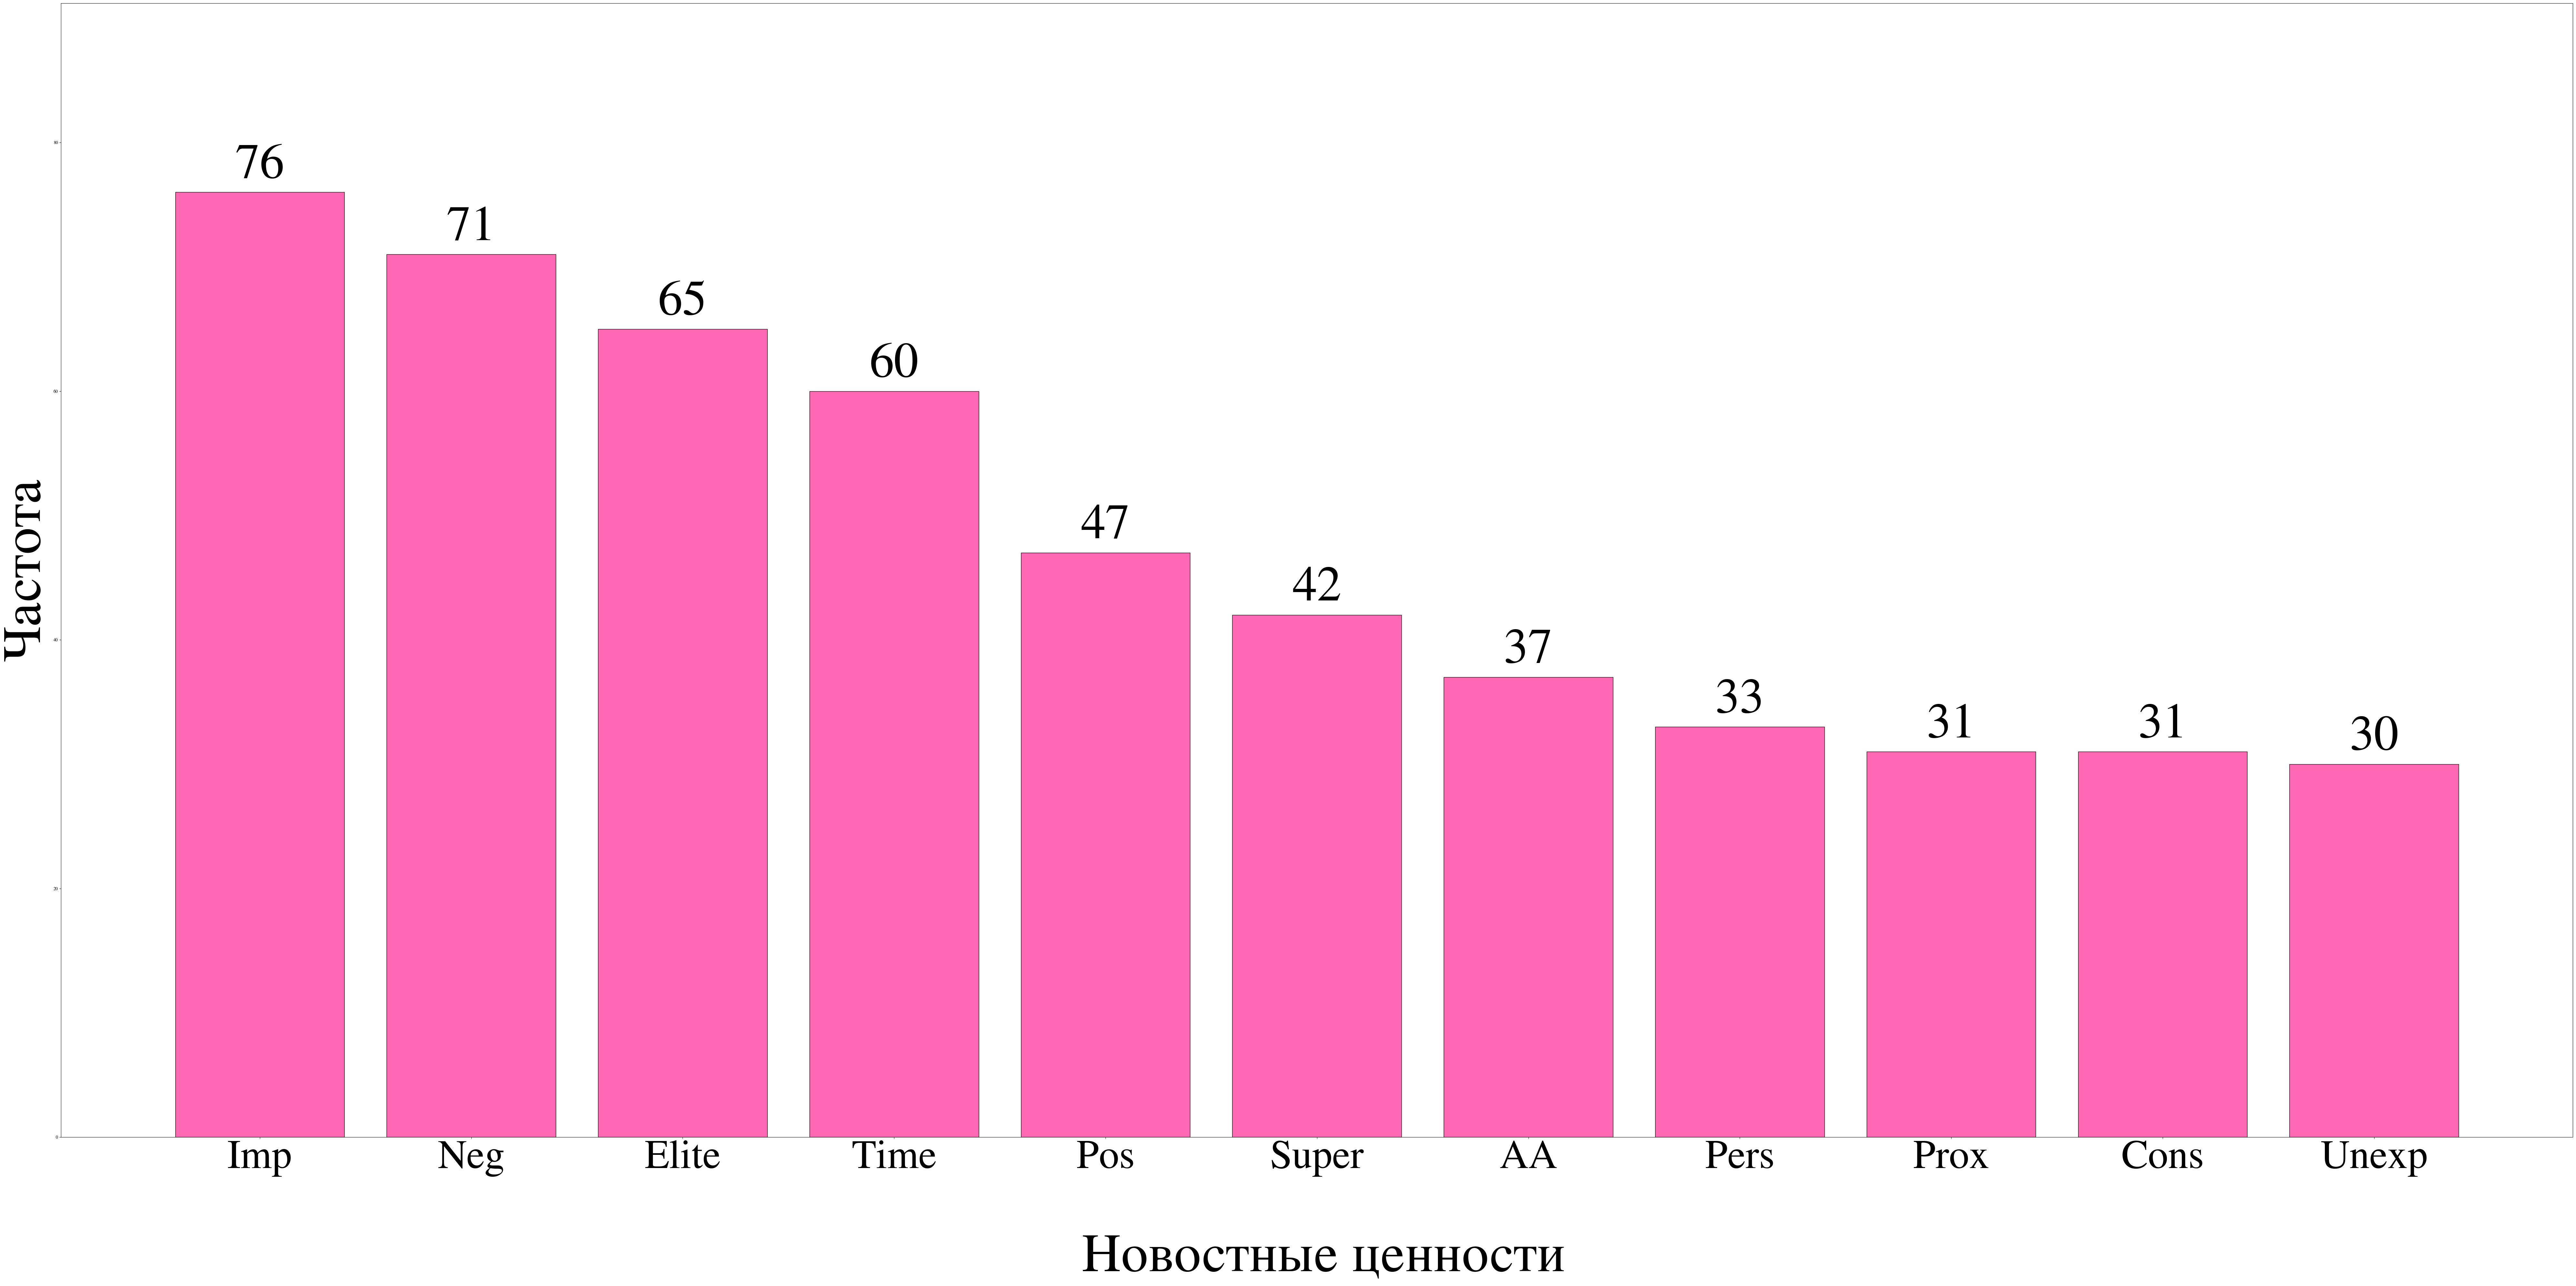

In [17]:
sorted_items = sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)
tags_plot = [item[0] for item in sorted_items]
counts_plot = [item[1] for item in sorted_items]


plt.figure(figsize=(80, 40))
plt.bar(tags_plot, counts_plot, color='hotpink', edgecolor='black')
plt.xlabel('\n Новостные ценности', fontsize=120)
plt.ylabel('Частота', fontsize=120)
plt.title('', fontsize=140) # Общая частотность тегов (текст + изображение)
plt.xticks(fontsize=90)

for i, v in enumerate(counts_plot):
    plt.text(i, v + 0.3, str(v), ha='center', va='bottom', fontsize=110)

plt.ylim(0, max(counts_plot) * 1.2)
plt.tight_layout()
plt.show()

## 2 – 3. Частотность тегов в текстах

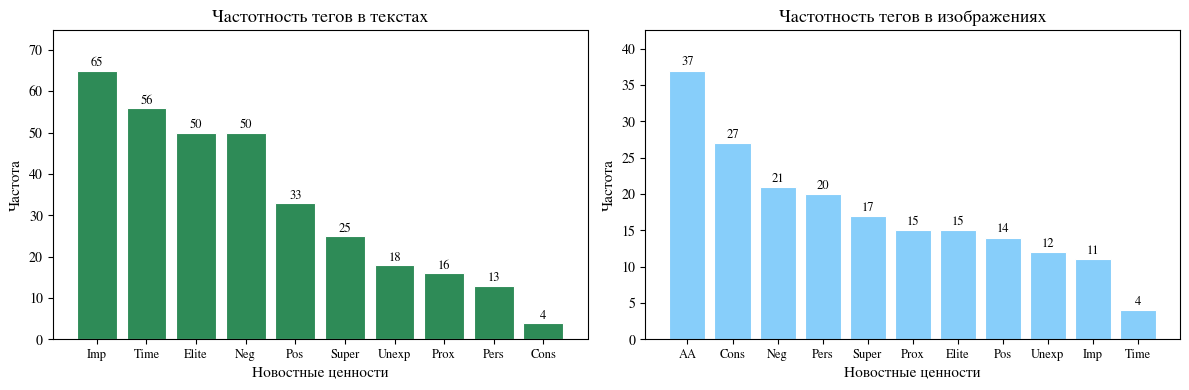

In [9]:
text_all = ' '.join(df['values_text'].fillna('').astype(str)).replace('\n', ' ')
image_all = ' '.join(df['values_image'].fillna('').astype(str)).replace('\n', ' ')
text_all = ' '.join(text_all.split())
image_all = ' '.join(image_all.split())

counts_text = Counter(text_all.split())
counts_image = Counter(image_all.split())

sorted_text = sorted(counts_text.items(), key=lambda x: x[1], reverse=True)
sorted_image = sorted(counts_image.items(), key=lambda x: x[1], reverse=True)

tags_text = [item[0] for item in sorted_text]
vals_text = [item[1] for item in sorted_text]

tags_image = [item[0] for item in sorted_image]
vals_image = [item[1] for item in sorted_image]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars1 = ax1.bar(tags_text, vals_text, color='#2E8B57', edgecolor='white', linewidth=0.8)
ax1.set_xlabel('Новостные ценности', fontsize=11)
ax1.set_ylabel('Частота', fontsize=11)
ax1.set_title('Частотность тегов в текстах', fontsize=13)
ax1.tick_params(axis='x', labelsize=9)
ax1.set_ylim(0, max(vals_text) * 1.15)
for bar, v in zip(bars1, vals_text):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v), ha='center', va='bottom', fontsize=9)

bars2 = ax2.bar(tags_image, vals_image, color='lightskyblue', edgecolor='white', linewidth=0.8)
ax2.set_xlabel('Новостные ценности', fontsize=11)
ax2.set_ylabel('Частота', fontsize=11)
ax2.set_title('Частотность тегов в изображениях', fontsize=13)
ax2.tick_params(axis='x', labelsize=9)
ax2.set_ylim(0, max(vals_image) * 1.15)
for bar, v in zip(bars2, vals_image):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#  4. Процент совпадения тегов (текст-картинка)


In [10]:
def split_tags(cell):
    if pd.isna(cell):
        return set()
    items = re.split(r'[ \n]+', str(cell))
    return {item.strip() for item in items if item.strip()}

df['text_tags_set'] = df['values_text'].apply(split_tags)
df['image_tags_set'] = df['values_image'].apply(split_tags)

df['text_tags_set'] = df['text_tags_set'].apply(lambda tags: {t for t in tags if t != 'AA'})
df['image_tags_set'] = df['image_tags_set'].apply(lambda tags: {t for t in tags if t != 'AA'})

overlap_percentages = []

for idx, row in df.iterrows():
    text_tags = row['text_tags_set']
    image_tags = row['image_tags_set']

    if not text_tags and not image_tags:
        overlap = 100.0
    elif not text_tags or not image_tags:
        overlap = 0.0
    else:
        intersection = len(text_tags & image_tags)
        union = len(text_tags | image_tags)
        overlap = (intersection / union) * 100

    overlap_percentages.append(overlap)

df['overlap_percentage'] = overlap_percentages

mean_overlap = sum(overlap_percentages) / len(overlap_percentages)
print(f"Средний процент совпадения тегов (текст vs картинка, без AA): {mean_overlap:.2f}%")


Средний процент совпадения тегов (текст vs картинка, без AA): 22.59%


## 5. Какие теги чаще совпадают, кроме АА

In [11]:
all_tags = set()
for tags in df['text_tags_set']:
    all_tags.update(tags)
for tags in df['image_tags_set']:
    all_tags.update(tags)

tag_match_stats = {}

for tag in all_tags:
    both = 0
    either = 0

    for idx, row in df.iterrows():
        in_text = tag in row['text_tags_set']
        in_image = tag in row['image_tags_set']

        if in_text or in_image:
            either += 1
        if in_text and in_image:
            both += 1

    match_percent = (both / either * 100) if either > 0 else 0
    tag_match_stats[tag] = (match_percent, both, either)

sorted_tags = sorted(tag_match_stats.items(), key=lambda x: x[1][0], reverse=True)

print("Какие теги чаще совпадают (без AA)")
for tag, (percent, both, either) in sorted_tags:
    print(f"{tag}: {percent:.1f}% ({both} совпадений из {either} новостей)")   # второе число - число новостей, где есть хотя бы 1 такой тег

Какие теги чаще совпадают (без AA)
Neg: 31.5% (17 совпадений из 54 новостей)
Super: 31.2% (10 совпадений из 32 новостей)
Prox: 24.0% (6 совпадений из 25 новостей)
Pos: 23.7% (9 совпадений из 38 новостей)
Elite: 22.6% (12 совпадений из 53 новостей)
Pers: 22.2% (6 совпадений из 27 новостей)
Unexp: 20.0% (5 совпадений из 25 новостей)
Imp: 11.8% (8 совпадений из 68 новостей)
Cons: 10.7% (3 совпадений из 28 новостей)
Time: 5.3% (3 совпадений из 57 новостей)


## 6. Heatmap для ценностей в текстах

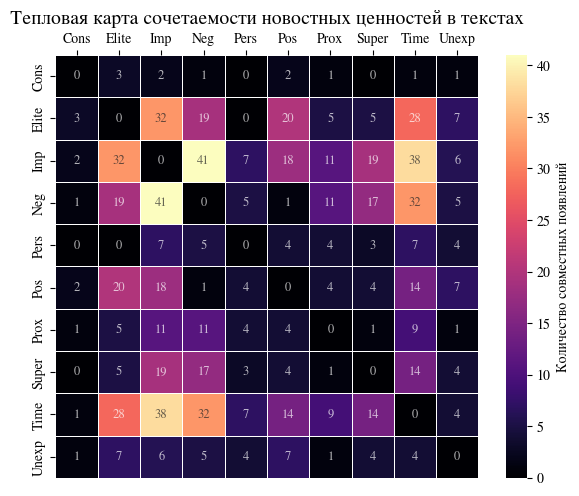

In [12]:
all_tags = ['Cons', 'Elite', 'Imp', 'Neg', 'Pers', 'Pos', 'Prox', 'Super', 'Time', 'Unexp']

co_occurrence = pd.DataFrame(0, index=all_tags, columns=all_tags, dtype=int)

for tags in df['text_tags_set']:
    tags_list = list(tags)
    for i, tag1 in enumerate(tags_list):
        for tag2 in tags_list[i+1:]:
            co_occurrence.loc[tag1, tag2] += 1
            co_occurrence.loc[tag2, tag1] += 1

plt.figure(figsize=(6, 5))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='magma',
            linewidths=0.5, square=True,
            annot_kws={'alpha': 0.7, 'size': 9},
            cbar_kws={'label': 'Количество совместных появлений'},
            xticklabels=True, yticklabels=True)

plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position('top')

plt.title('Тепловая карта сочетаемости новостных ценностей в текстах', fontsize=14)
plt.tight_layout()
plt.show()

#  7. Heatmap для ценностей в картинках

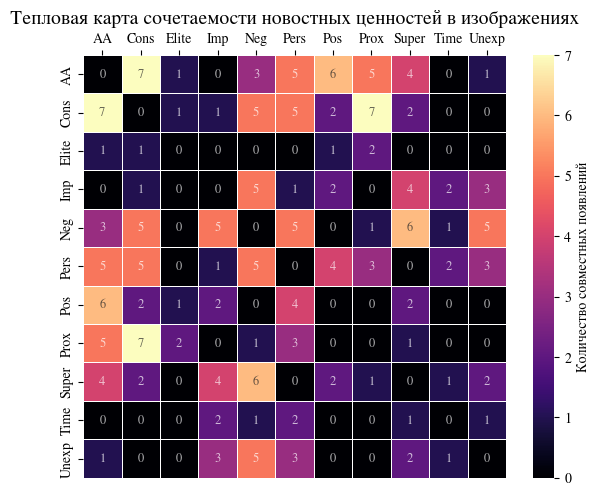

In [21]:
def parse_tags(tag_string):
    if pd.isna(tag_string):
        return []
    return [tag.strip() for tag in str(tag_string).split('\n') if tag.strip()]

df['image_tags_set'] = df['values_image'].apply(parse_tags)

all_tags_image = sorted(set(
    tag for tags in df['image_tags_set']
    for tag in tags
))

co_occurrence_image = pd.DataFrame(0, index=all_tags_image, columns=all_tags_image, dtype=int)

for tags in df['image_tags_set']:
    tags_list = tags
    for i, tag1 in enumerate(tags_list):
        for tag2 in tags_list[i+1:]:
            co_occurrence_image.loc[tag1, tag2] += 1
            co_occurrence_image.loc[tag2, tag1] += 1

plt.figure(figsize=(6, 5))
sns.heatmap(co_occurrence_image, annot=True, fmt='d', cmap='magma',
            linewidths=0.5, square=True,
            annot_kws={'alpha': 0.7, 'size': 9},
            cbar_kws={'label': 'Количество совместных появлений'},
            xticklabels=True, yticklabels=True)

plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position('top')

plt.title('Тепловая карта сочетаемости новостных ценностей в изображениях', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Где в среднем больше тегов на новость, в тексте или в картинке?

In [14]:
df['text_tag_count'] = df['text_tags_set'].apply(len)
df['image_tag_count'] = df['image_tags_set'].apply(len)

mean_text = df['text_tag_count'].mean()
mean_image = df['image_tag_count'].mean()

print(f"Среднее количество тегов на новость: {((mean_image + mean_text) / 2):.2f}")
print(f"Среднее количество тегов на новость в ТЕКСТАХ: {mean_text:.2f}")
print(f"Среднее количество тегов на новость в ИЗОБРАЖЕНИЯХ: {mean_image:.2f}")
print(f"Разница: {mean_text - mean_image:.2f} (текст {'больше' if mean_text > mean_image else 'меньше'} картинки)")



Среднее количество тегов на новость: 2.43
Среднее количество тегов на новость в ТЕКСТАХ: 3.30
Среднее количество тегов на новость в ИЗОБРАЖЕНИЯХ: 1.56
Разница: 1.74 (текст больше картинки)


## 9. Связь между типом новости и типом отношения текст-картинка

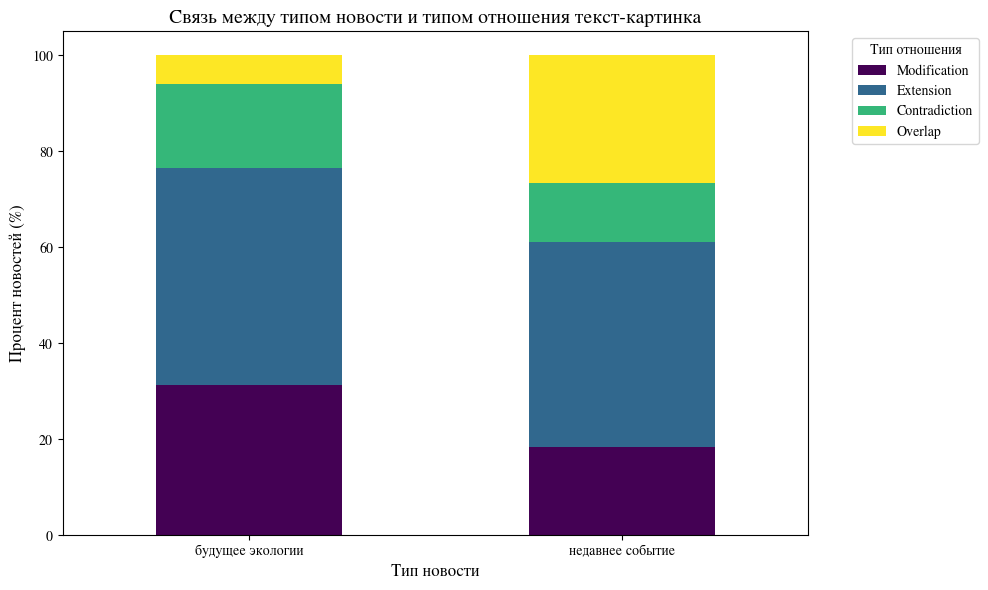

Таблица сопряжённости (% по строкам):
relation          Contradiction  Extension  Modification  Overlap
news_type                                                        
будущее экологии           17.6       45.1          31.4      5.9
недавнее событие           12.2       42.9          18.4     26.5

Хи-квадрат: 8.86
p-value: 0.0311
Связь статистически значима (p < 0.05)


In [15]:
crosstab = pd.crosstab(df['news_type'], df['relation'], normalize='index') * 100

ax = crosstab[['Modification', 'Extension', 'Contradiction', 'Overlap']].plot(
    kind='bar', stacked=True, figsize=(10, 6), colormap='viridis'
)

plt.xlabel('Тип новости', fontsize=12)
plt.ylabel('Процент новостей (%)', fontsize=12)
plt.title('Связь между типом новости и типом отношения текст-картинка', fontsize=14)
plt.legend(title='Тип отношения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Таблица сопряжённости (% по строкам):")
print(crosstab.round(1))

from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['news_type'], df['relation'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"\nХи-квадрат: {chi2:.2f}")
print(f"p-value: {p:.4f}")
if p < 0.05:
    print("Связь статистически значима (p < 0.05)")
else:
    print("Статистически значимой связи не обнаружено")
